In [ ]:
# %pip --version

In [ ]:
# !pip install keras-cv==0.6.1 keras-core==0.1.0 tensorflow==2.13.1 tensorflow-datasets==4.9.7

In [1]:
import json
import math
import keras_cv
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import losses
import numpy as np
from keras import metrics
import matplotlib.pyplot as plt
import os

In [2]:
file='lions_cheetahs.zip'
if not os.path.exists(file):
    # Download the dataset from the Internet Archive
    # Uncomment the line below to download the dataset if you haven't already downloaded it
    %wget -nc https://archive.org/download/lions_cheetahs/lions_cheetahs.zip
    %unzip -nq lions_cheetahs.zip

In [3]:
!ls

00-Preinstall.ipynb
10-Pretrained_Classifier.ipynb
11-Fine_Tune_Classifier.ipynb
12-Pretrained_Object_Detection.ipynb
21-Train_Object_Detection_Simple-failed.ipynb
22-Train_Object_Detection_Custom_Dataset-failed.ipynb
30-Stable_Diffusion_1.ipynb
30-Stable_Diffusion_2.ipynb
30-Stable_Diffusion_3_(Mixed_Precision_+_JIT).ipynb
SelfDrivingCar.v3-fixed-small.coco
california_quail.jpg
images
lions_cheetahs.zip


In [4]:
!ls images
# we need to train-validation split manually
# confirm folder structure

Cheetahs
Lions


In [5]:
!ls images/Cheetahs/

0052cb267268c59e.jpg
00707659aba29334.jpg
007f9ffc01c7b106.jpg
00bb45a8568a3474.jpg
00c8d36882dd6d37.jpg
00d100b0231b60e6.jpg
00d9eb862ba3dfc6.jpg
012f5ecbf49e1da0.jpg
01750ba1a197e3ad.jpg
01d688c043bdbfbb.jpg
0230496e4a8ed917.jpg
02871f24d5abe59c.jpg
029b39c0b65ebeb3.jpg
02a0439923768403.jpg
02a5846a35629f1d.jpg
02b086c4e96396f6.jpg
02dd8dd4344b04a7.jpg
0321448f2848ab99.jpg
038182259bcc5bc0.jpg
039d20705ddc6162.jpg
03c7118d468d94aa.jpg
03e4a856df44695a.jpg
03f680447efaccfe.jpg
048b18e2e692a424.jpg
049fc60b9efd187b.jpg
055dbbcca8626dbb.jpg
05632fadcb5e1e9c.jpg
06434b4d5989df37.jpg
07642e275bb2b869.jpg
07b7a0704a9a543b.jpg
08108fb36d20a11d.jpg
09017fd0f60f309a.jpg
09ead945be525356.jpg
0ae4f7841c26ba0d.jpg
0c20fa69621a2e6c.jpg
0c61b8d86a3e0889.jpg
0c6e90e19f2b2bbc.jpg
0db6601682a368e8.jpg
0fb021bac7207533.jpg
11377ee99115ffff.jpg
113fbf2203ccef57.jpg
1140e3015190cfeb.jpg
11c270e6589dce6e.jpg
12271a9ed07dc28e.jpg
135b67b72eb7bb47.jpg
13626a8bd4c27b49.jpg
13cec8f6c995afba.jpg
150bf6ac5d17e

In [6]:
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    'images',
    image_size=(224, 224),
    validation_split=0.3,
    subset='both',
    seed=123,
)

Found 200 files belonging to 2 classes.
Using 140 files for training.
Using 60 files for validation.


In [8]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [10]:
# Shuffle the dataset to increase diversity of batches.
train_ds = train_ds.shuffle(
    10 * 32, reshuffle_each_iteration=True
)

(32, 224, 224, 3)


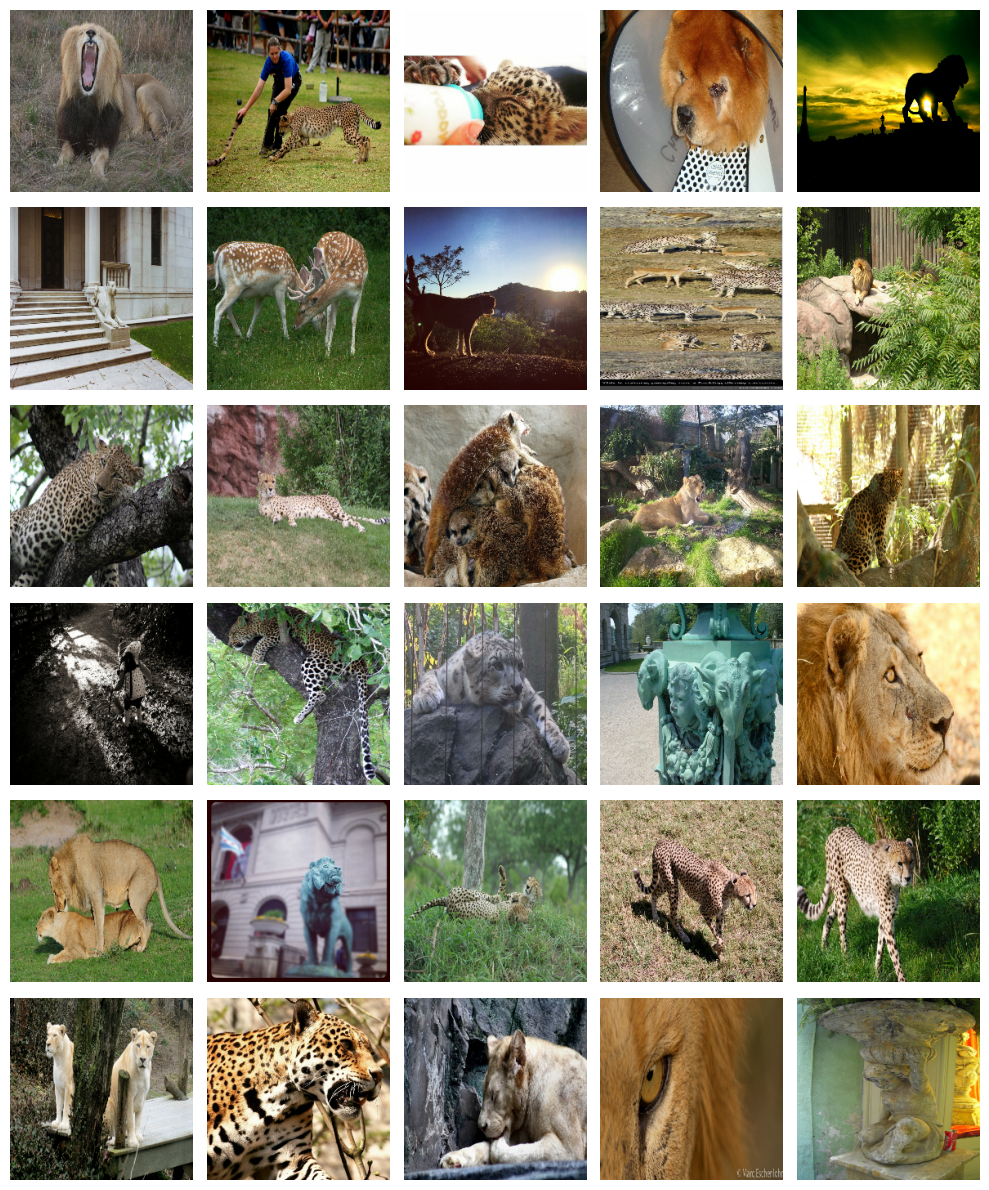

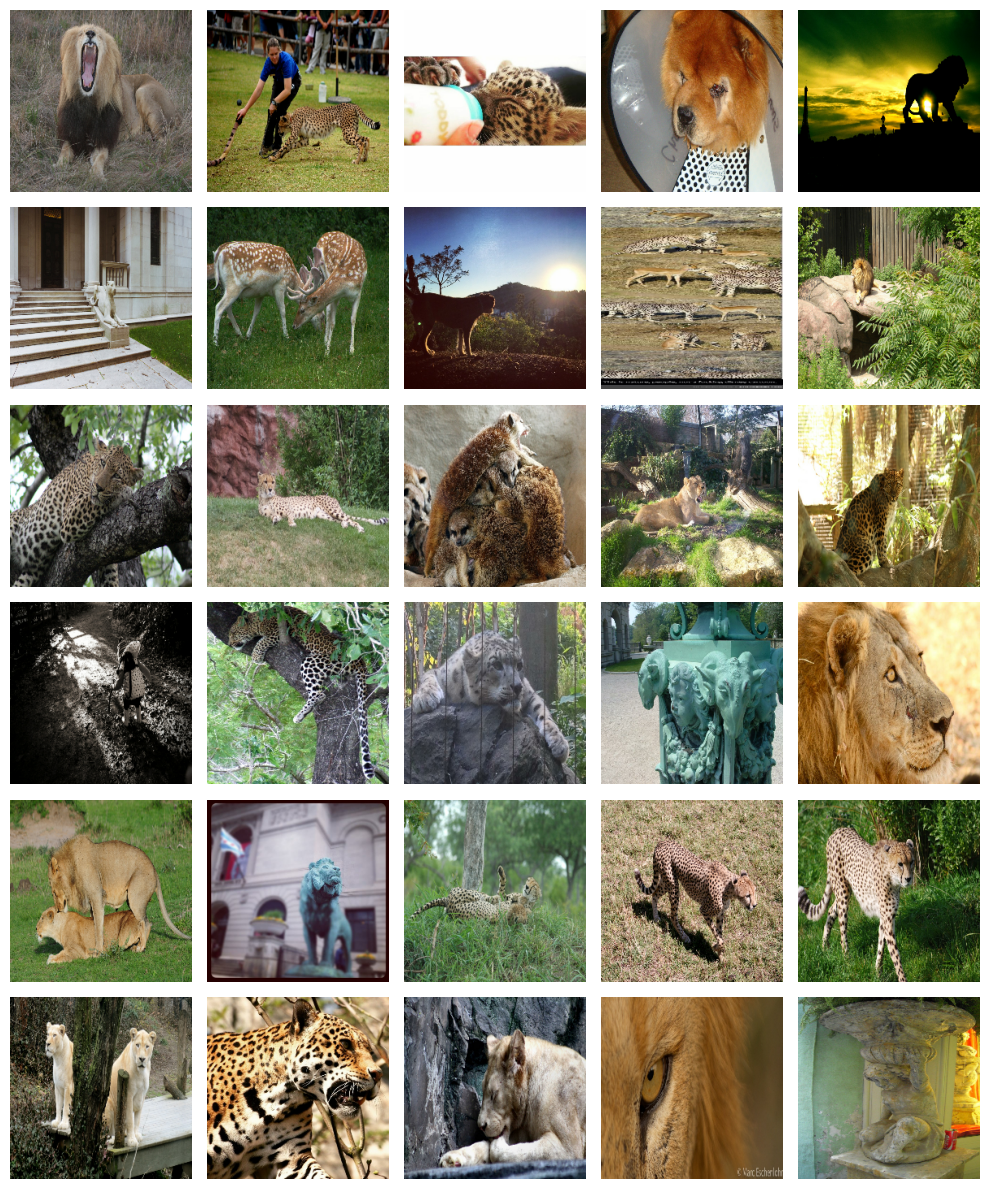

In [11]:
images = next(iter(train_ds.take(1)))[0]
print(images.shape)
keras_cv.visualization.plot_image_gallery(images, value_range=(0, 255))

In [12]:
model = keras_cv.models.ImageClassifier.from_preset(
    "efficientnetv2_b0_imagenet", num_classes=2
)
model.compile(
    loss="sparse_categorical_crossentropy",
    # optimizer=tf.optimizers.SGD(learning_rate=0.01),
    optimizer=tf.keras.optimizers.AdamW(),
    metrics=["accuracy"],
)

In [14]:
r = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9857 - loss: 0.0293 - val_accuracy: 0.8167 - val_loss: 0.5357
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9857 - loss: 0.0336 - val_accuracy: 0.8833 - val_loss: 0.3786
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9929 - loss: 0.0195 - val_accuracy: 0.8833 - val_loss: 0.3174
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 1.0000 - loss: 0.0144 - val_accuracy: 0.8833 - val_loss: 0.2800
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9929 - loss: 0.0177 - val_accuracy: 0.8833 - val_loss: 0.2175
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9929 - loss: 0.0209 - val_accuracy: 0.8833 - val_loss: 0.2708
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9857 - loss: 0.0271 - val_accuracy: 0.8333 - val_loss: 0.3293
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 1.0000 - loss: 0.0095 - val_accuracy: 0.8167 - val_loss: 0.3910
Epoch 9/1

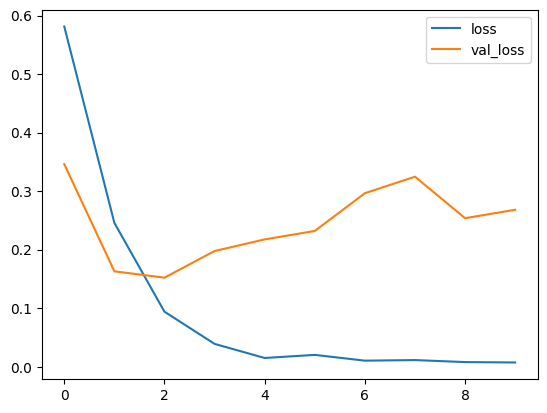

In [23]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend();

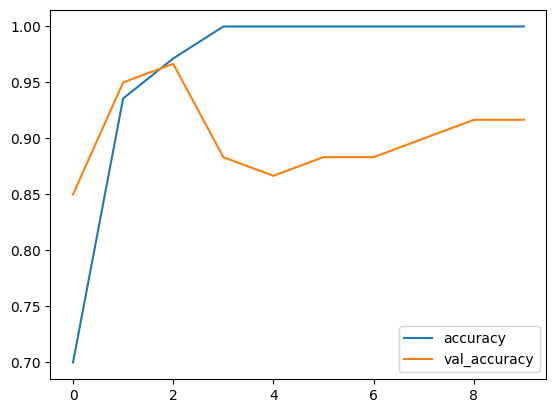

In [24]:
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend();

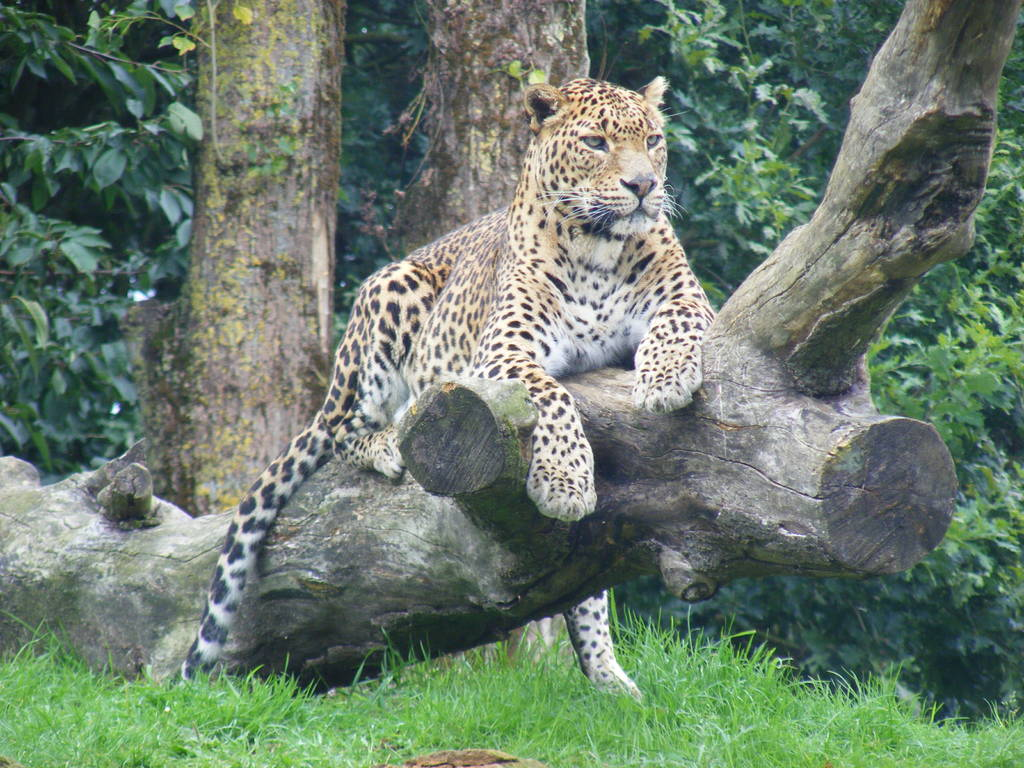

In [25]:
# Make a prediction on a single image
from PIL import Image

path = 'images/Cheetahs/ed51aa4321f10a21.jpg'
im = Image.open(path)
im

In [26]:
type(im)

PIL.JpegImagePlugin.JpegImageFile

In [27]:
np_im = np.asarray(im)

In [28]:
np_im.shape

(768, 1024, 3)

In [29]:
resizing = keras_cv.layers.Resizing(
    224, 224, crop_to_aspect_ratio=True
)

In [30]:
resizing

<Resizing name=resizing, built=True>

In [31]:
np_im_rs = resizing(np_im)
np_im_rs

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[ 42.4949  ,  56.209183,  51.94388 ],
        [ 46.663265,  72.81122 ,  58.23469 ],
        [ 96.311226, 133.68367 , 116.34183 ],
        ...,
        [ 55.928608,  80.35718 ,  83.14293 ],
        [ 55.07668 ,  78.22461 ,  86.28593 ],
        [ 59.423473,  82.06633 ,  94.39796 ]],

       [[ 43.42347 ,  82.5     ,  41.918365],
        [ 77.63775 , 119.20918 ,  90.051025],
        [105.90306 , 146.36224 , 133.7857  ],
        ...,
        [ 34.734688,  66.0204  ,  52.806118],
        [ 48.82666 ,  80.11237 ,  67.61237 ],
        [ 42.872494,  74.15821 ,  61.658207]],

       [[ 79.239784, 122.85713 ,  74.27039 ],
        [ 80.67346 , 127.244896,  73.959175],
        [ 69.41837 , 117.34694 ,  66.19387 ],
        ...,
        [ 47.051003,  79.12243 ,  63.979576],
        [ 28.734863,  66.52058 ,  43.592007],
        [ 49.852028,  89.311195,  63.979588]],

       ...,

       [[133.6836  , 191.75505 , 139.541   ],
        [ 93.

In [32]:
np_im_rs.shape

TensorShape([224, 224, 3])

In [33]:
x = tf.reshape(np_im_rs, (1, 224, 224, 3))

In [34]:
out = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [35]:
out

array([[9.9979049e-01, 2.0950759e-04]], dtype=float32)

In [36]:
val_ds.class_names

['Cheetahs', 'Lions']